
# CVL_Assignment01
## Image Enhancement for Dark / Low-Light Image

**Tujuan:** Mengimplementasikan teknik peningkatan citra cahaya rendah untuk citra gelap atau minim cahaya menggunakan **Koreksi Gamma** dan **CLAHE (Contrast Limited Adaptive Histogram Equalization)**.

**Metode yang digunakan:**

1. **Koreksi Gamma** — meningkatkan kecerahan citra.
2. **CLAHE** — meningkatkan kontras lokal dengan membatasi penguatan kontras untuk membantu mengurangi amplifikasi noise yang berlebihan.

Citra low-light asli dibandingkan dengan hasil peningkatan untuk melihat perubahan kecerahan dan kontras. Selain itu, histogram intensitas digunakan untuk menganalisis perubahan distribusi piksel sebelum dan sesudah enhancement.


In [1]:

# Install required libraries (uncomment if needed)
# !pip install opencv-python matplotlib scikit-image numpy


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [8]:
uploaded = files.upload()

Saving image2.jpg to image2.jpg


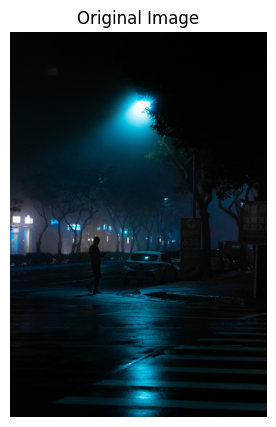

In [9]:
filename = next(iter(uploaded))

image = cv2.imread(filename)

if image is None:
    raise ValueError("Gambar gagal dibaca")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()


## Gamma Correction

Gamma correction mengubah intensitas piksel menggunakan:

I_out = 255 × (I_in / 255)^γ

Untuk gambar gelap, nilai **gamma < 1** membuat gambar lebih terang. Di sini, kita menggunakan `gamma = 0,5`.

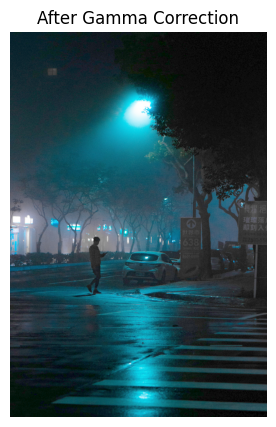

In [13]:
def gamma_correction(image, gamma=0.5):
    table = np.array([
        ((i / 255.0) ** gamma) * 255
        for i in np.arange(256)
    ]).astype("uint8")

    return cv2.LUT(image, table)


gamma_image = gamma_correction(image, gamma=0.5)

gamma_rgb = cv2.cvtColor(
    gamma_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 5))

plt.imshow(gamma_rgb)
plt.title("After Gamma Correction")
plt.axis("off")

plt.show()


## CLAHE Enhancement

CLAHE meningkatkan kontras lokal dengan membagi gambar menjadi wilayah-wilayah kecil (ubin). Peningkatan ini diterapkan pada saluran **L (kecerahan)** dalam ruang warna LAB sehingga informasi warna lebih terjaga.


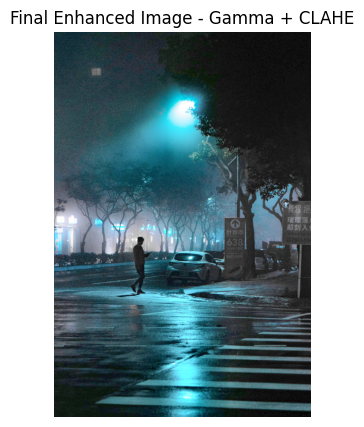

In [14]:
def apply_clahe(image):

    # Convert BGR to LAB
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    # Split LAB channels
    l, a, b = cv2.split(lab)

    # Create CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    # Apply CLAHE to L channel
    l_enhanced = clahe.apply(l)

    # Merge channels
    lab_enhanced = cv2.merge(
        (l_enhanced, a, b)
    )

    # Convert back to BGR
    enhanced_image = cv2.cvtColor(
        lab_enhanced,
        cv2.COLOR_LAB2BGR
    )

    return enhanced_image


enhanced_image = apply_clahe(gamma_image)

enhanced_rgb = cv2.cvtColor(
    enhanced_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 5))

plt.imshow(enhanced_rgb)
plt.title("Final Enhanced Image - Gamma + CLAHE")
plt.axis("off")

plt.show()


## Perbandingan Hasil


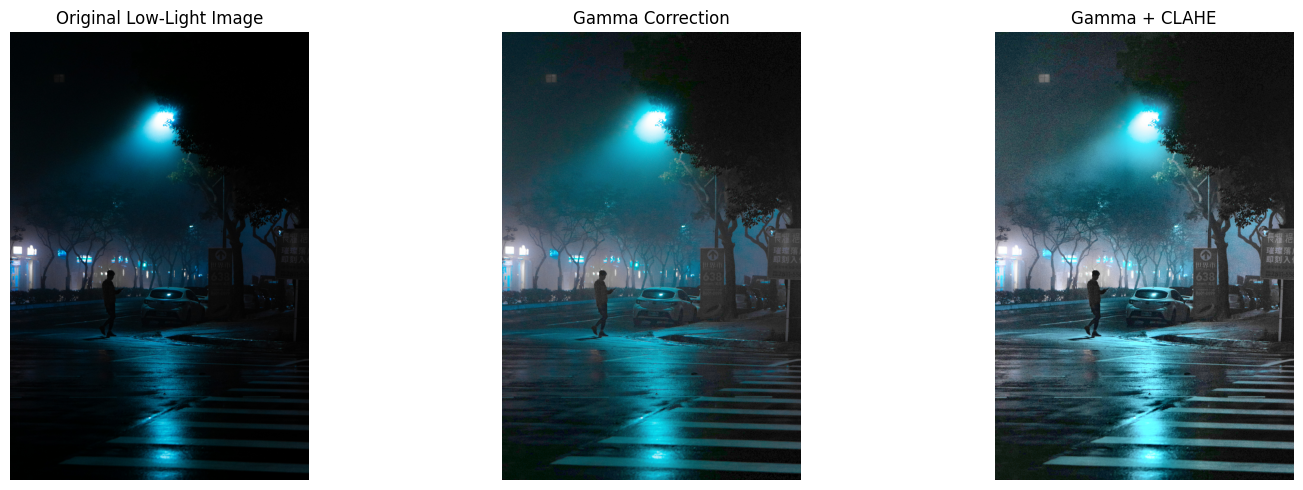

In [15]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Low-Light Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gamma_rgb)
plt.title("Gamma Correction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(enhanced_rgb)
plt.title("Gamma + CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()


## Histogram Comparison

Histogram menunjukkan distribusi nilai intensitas piksel. Untuk gambar gelap, nilai piksel terkonsentrasi pada intensitas yang lebih rendah. Setelah peningkatan kualitas, distribusi akan menyebar ke arah nilai intensitas yang lebih terang dan memiliki kontras yang lebih baik.


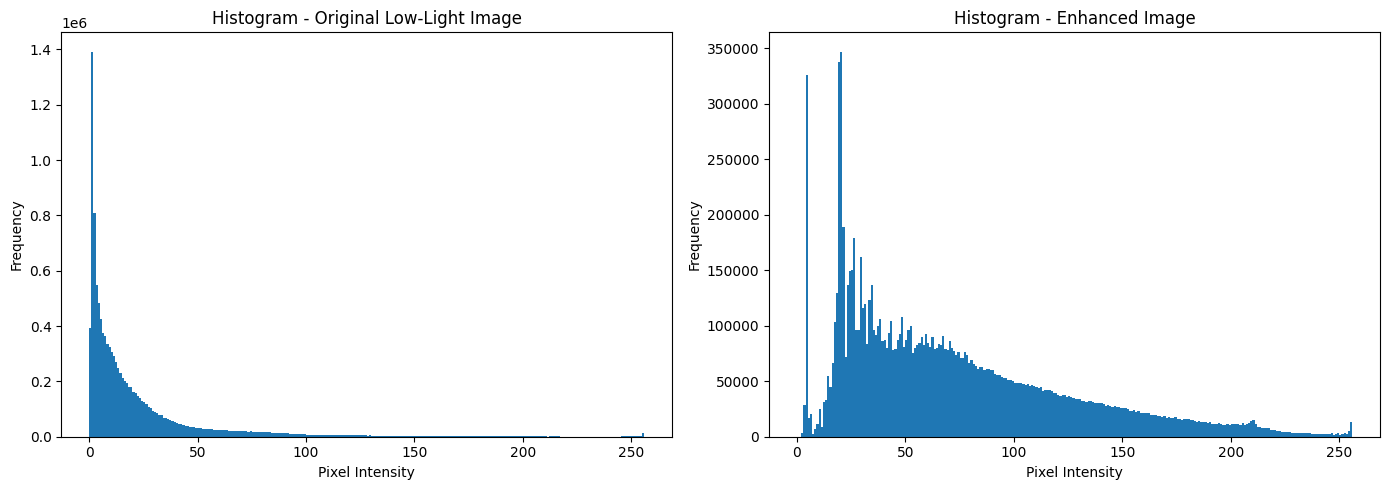

In [16]:
original_gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)

enhanced_gray = cv2.cvtColor(
    enhanced_image,
    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.hist(
    original_gray.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram - Original Low-Light Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")


plt.subplot(1, 2, 2)

plt.hist(
    enhanced_gray.ravel(),
    bins=256,
    range=[0, 256]
)

plt.title("Histogram - Enhanced Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Evaluasi Kuantitatif

**Kecerahan Rata-rata** — nilai yang lebih tinggi umumnya menunjukkan gambar yang lebih terang.

**Deviasi Standar** — dapat digunakan sebagai indikator sederhana kontras. Nilai yang lebih besar biasanya berarti nilai intensitas lebih tersebar.

In [17]:
original_mean = np.mean(original_gray)
original_std = np.std(original_gray)

enhanced_mean = np.mean(enhanced_gray)
enhanced_std = np.std(enhanced_gray)

print("=== ORIGINAL LOW-LIGHT IMAGE ===")
print(f"Mean Brightness : {original_mean:.2f}")
print(f"Contrast (Std)  : {original_std:.2f}")

print("\n=== ENHANCED IMAGE ===")
print(f"Mean Brightness : {enhanced_mean:.2f}")
print(f"Contrast (Std)  : {enhanced_std:.2f}")

=== ORIGINAL LOW-LIGHT IMAGE ===
Mean Brightness : 20.90
Contrast (Std)  : 30.82

=== ENHANCED IMAGE ===
Mean Brightness : 72.94
Contrast (Std)  : 52.73


In [18]:
brightness_change = enhanced_mean - original_mean
contrast_change = enhanced_std - original_std

print("=== ENHANCEMENT RESULT ===")

print(f"Brightness change : {brightness_change:.2f}")
print(f"Contrast change   : {contrast_change:.2f}")

=== ENHANCEMENT RESULT ===
Brightness change : 52.05
Contrast change   : 21.91



## Kesimpulan

Citra cahaya redup berhasil ditingkatkan menggunakan kombinasi Koreksi Gamma dan CLAHE.

Koreksi Gamma digunakan untuk meningkatkan kecerahan keseluruhan citra, sedangkan CLAHE digunakan untuk meningkatkan kontras lokal dan mempertajam detail di area yang lebih gelap.

Perbandingan visual dan analisis histogram menunjukkan perubahan intensitas citra setelah peningkatan. Kecerahan rata-rata dan deviasi standar juga memberikan informasi kuantitatif tentang perubahan kecerahan dan kontras.

Oleh karena itu, kombinasi Koreksi Gamma dan CLAHE dapat digunakan sebagai pendekatan peningkatan citra sederhana untuk citra cahaya redup.